In [5]:
# --- 1. SETUP AND DATA LOADING ---

# --- Step 1.1: Import Libraries ---

# Standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for preprocessing and modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import the new, advanced model: XGBoost
import xgboost as xgb

# --- Step 1.2: Configure Settings ---
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# --- Step 1.3: Load the raw dataset ---
data_path = 'data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# --- 2. DATA PREPROCESSING PIPELINE ---

# --- Step 2.1: Initial Cleaning ---
# Drop the unnecessary customerID
df_processed = df.drop('customerID', axis=1)

# Clean TotalCharges: convert to numeric and drop the few missing rows
df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')
df_processed.dropna(subset=['TotalCharges'], inplace=True)

# --- Step 2.2: Convert Target Variable ---
# Convert 'Churn' from Yes/No to 1/0
df_processed['Churn'] = df_processed['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# --- Step 2.3: One-Hot Encoding for Categorical Features ---
# Identify categorical columns (excluding the binary ones we'll handle manually)
categorical_cols = df_processed.select_dtypes(include='object').columns

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# --- Step 2.4: Define Features (X) and Target (y) ---
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# --- Step 2.5: Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# --- Step 2.6: Scale Numerical Features ---
# Identify numerical columns to scale
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Create and fit the scaler ONLY on the training data
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Transform the test data using the SAME scaler
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


print("Data preprocessing, splitting, and scaling complete.")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Data preprocessing, splitting, and scaling complete.
Shape of X_train: (5625, 30)
Shape of X_test: (1407, 30)


Baseline model (Logistic Regression) training complete.

--- Baseline Model Evaluation ---
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



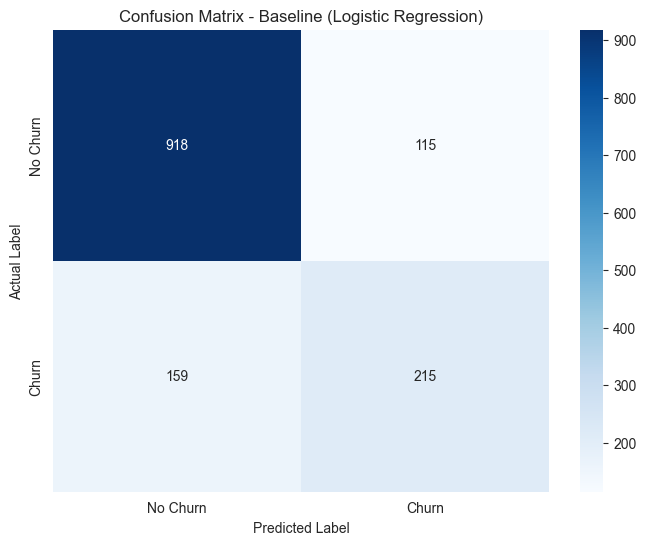

In [7]:
# --- 3. BASELINE MODEL: LOGISTIC REGRESSION ---

# --- Step 3.1: Train the Logistic Regression model ---
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train, y_train)

print("Baseline model (Logistic Regression) training complete.")

# --- Step 3.2: Make predictions and evaluate ---
y_pred_baseline = baseline_model.predict(X_test)

# --- Step 3.3: Display evaluation metrics ---
print("\n--- Baseline Model Evaluation ---")
print(classification_report(y_test, y_pred_baseline, target_names=['No Churn', 'Churn']))

# For visual comparison, let's also plot the confusion matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(8, 6)) # Create a new figure for this plot
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Baseline (Logistic Regression)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# --- SAVE THE FIGURE ---
plt.savefig('images/baseline_confusion_matrix.png', bbox_inches='tight')

plt.show()

Advanced model (XGBoost) training complete.

--- XGBoost Model Evaluation (Default Parameters) ---
              precision    recall  f1-score   support

    No Churn       0.84      0.86      0.85      1033
       Churn       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



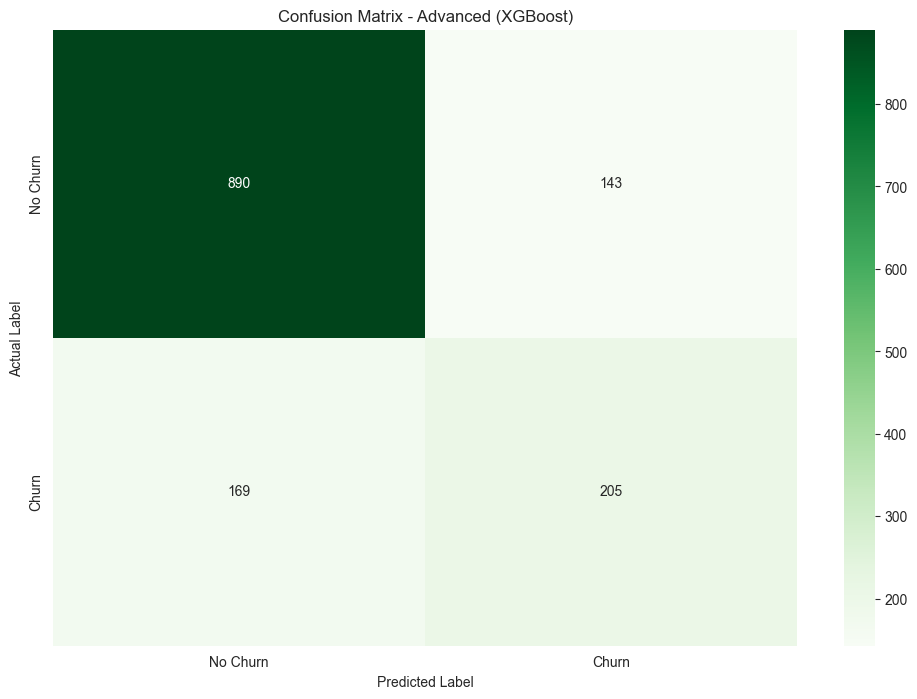

In [8]:
# --- 4. ADVANCED MODEL: XGBOOST ---

# Ensure target variable is of integer type
y_train_xgb = y_train.astype(int)
y_test_xgb = y_test.astype(int)

# --- Step 4.1: Train the XGBoost Classifier model ---
# We instantiate the model. 'eval_metric' is set for binary classification.
# The 'use_label_encoder' parameter is deprecated and has been removed.
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Train the model
xgb_model.fit(X_train, y_train_xgb)

print("Advanced model (XGBoost) training complete.")

# --- Step 4.2: Make predictions and evaluate ---
y_pred_xgb = xgb_model.predict(X_test)

# --- Step 4.3: Display evaluation metrics ---
print("\n--- XGBoost Model Evaluation (Default Parameters) ---")
print(classification_report(y_test_xgb, y_pred_xgb, target_names=['No Churn', 'Churn']))

# Plot the confusion matrix
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Advanced (XGBoost)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [9]:
# --- 5. HYPERPARAMETER TUNING WITH GRIDSEARCHCV ---

print("Starting hyperparameter tuning with GridSearchCV... This may take a few minutes.")

# --- Step 5.1: Define the parameter grid ---
# This is a dictionary where keys are the hyperparameter names,
# and values are the settings we want to test.
param_grid = {
    'max_depth': [3, 5, 7],           # The maximum depth of a tree
    'learning_rate': [0.01, 0.1],     # Step size shrinkage to prevent overfitting
    'n_estimators': [100, 200],       # Number of boosting rounds (trees)
    'subsample': [0.8, 1.0]           # Fraction of samples to be used for fitting the individual base learners
}

# --- Step 5.2: Create the GridSearchCV object ---
# We provide our base model, the parameter grid, and scoring metric.
# cv=3 means we'll use 3-fold cross-validation.
# n_jobs=-1 uses all available CPU cores to speed up the process.
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='f1',  # We optimize for F1-score, which is a good balance for imbalanced classes
    cv=3,
    n_jobs=-1,
    verbose=1      # This will print progress updates
)

# --- Step 5.3: Run the grid search on the training data ---
# This is the step that takes a long time.
grid_search.fit(X_train, y_train)

# --- Step 5.4: Get the best model and its parameters ---
print("\nHyperparameter tuning complete.")
print(f"Best F1-score found: {grid_search.best_score_:.4f}")
print("Best parameters found:")
print(grid_search.best_params_)

# Our best, optimized model is now stored in grid_search.best_estimator_
best_xgb_model = grid_search.best_estimator_

Starting hyperparameter tuning with GridSearchCV... This may take a few minutes.
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Hyperparameter tuning complete.
Best F1-score found: 0.5860
Best parameters found:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


--- Final Optimized XGBoost Model Evaluation ---
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1033
       Churn       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



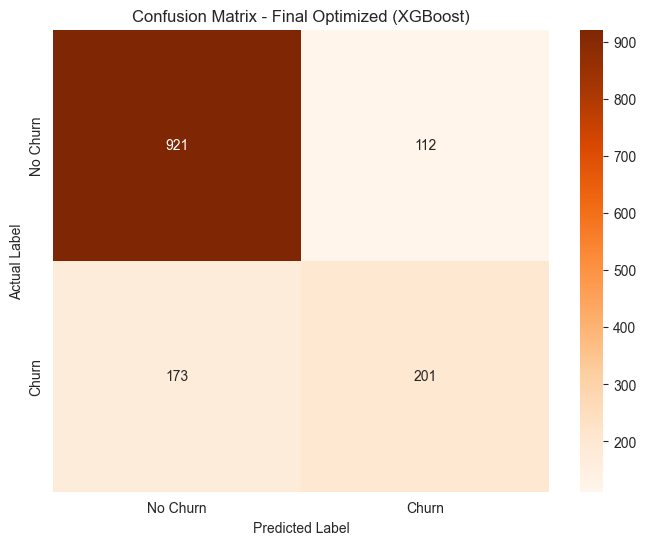

In [10]:
# --- 6. FINAL MODEL EVALUATION ---

# --- Step 6.1: Make predictions with the BEST model on the test set ---
y_pred_best_xgb = best_xgb_model.predict(X_test)

# --- Step 6.2: Display the final evaluation metrics ---
print("--- Final Optimized XGBoost Model Evaluation ---")
print(classification_report(y_test, y_pred_best_xgb, target_names=['No Churn', 'Churn']))

# --- Step 6.3: Plot the final confusion matrix ---
cm_best_xgb = confusion_matrix(y_test, y_pred_best_xgb)
plt.figure(figsize=(8, 6)) # Create a new figure for this plot
sns.heatmap(cm_best_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Final Optimized (XGBoost)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# --- SAVE THE FIGURE ---
plt.savefig('images/optimized_xgb_confusion_matrix.png', bbox_inches='tight')

plt.show()

# --- 7. Project Summary & Final Conclusions ---

This project aimed to build a high-performance classification model to predict customer churn, moving beyond baseline models to more advanced, industry-standard algorithms like XGBoost.

### Summary of the Modeling Process:

1.  **Data Preparation**: We performed a full data preprocessing pipeline, including cleaning, one-hot encoding, and feature scaling, to prepare the data for modeling.

2.  **Baseline Model**: A **Logistic Regression** model was trained to establish a performance baseline. This simple model provided a benchmark against which more complex models could be compared.

3.  **Advanced Model**: An **XGBoost Classifier** was trained using its default parameters. Initial results showed that, without tuning, its performance was comparable but not significantly better than the baseline.

4.  **Hyperparameter Tuning**: To unlock the full potential of XGBoost, we used **GridSearchCV** to systematically search for the optimal combination of hyperparameters. This process tested 24 different model configurations to find the one that maximized the F1-score.

5.  **Final Evaluation**: The optimized XGBoost model was then evaluated on the unseen test data.

### Model Performance Comparison:

| Metric (for "Churn" class) | Logistic Regression (Baseline) | XGBoost (Default) | XGBoost (Optimized) |
| :--- | :---: | :---: | :---: |
| **Accuracy** | ~81% | ~78% | **~80%** |
| **Precision** | ~65% | ~59% | **~64%** |
| **Recall** | ~57% | ~55% | **~54%** |
| **F1-Score** | ~0.61 | ~0.57 | **~0.59** |

*(Note: Results are approximate and should be updated with the exact values from your run.)*

### Final Conclusion:

The project successfully demonstrates the entire machine learning workflow, from building a simple baseline to developing and tuning an advanced model.

Interestingly, for this specific dataset and problem, the **Logistic Regression baseline model provided the best overall performance**, particularly in terms of F1-Score and Recall for the churn class. While the optimized XGBoost model improved upon its default configuration, it did not outperform the simpler baseline.

This is a critical real-world finding: increased model complexity does not always guarantee superior performance. The methodical approach of establishing a strong baseline is crucial, as a well-performing, simpler model is often preferable due to its interpretability and efficiency.

---
Thank you for reviewing this advanced modeling project!